# Исследование применимости предобученных на англоязычных наборах данных моделей детекции голосовых дипфейков к русскоязычным данным

In [1]:
import os 
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torch.nn.parameter import Parameter

from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")


DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device set to use: {DEVICE}")

Device set to use: cuda


In [2]:
DATASET_PATH = "../russian_sdd_dataset"

train_df = pd.read_csv(os.path.join(DATASET_PATH, 'train.csv'), index_col=0)
train_paths = [os.path.join(DATASET_PATH, audio) for audio in train_df['audio']]

test_df = pd.read_csv(os.path.join(DATASET_PATH, 'test.csv'), index_col=0)
test_paths = [os.path.join(DATASET_PATH, audio) for audio in test_df['audio']]

In [3]:
def load_audio(audio_path: str) -> torch.Tensor:
    sample_rate = 16_000
    
    wav, sr = torchaudio.load(audio_path)
        
    if sr != sample_rate:
        wav = torchaudio.transforms.Resample(sr, sample_rate)(wav)
            
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
            
    return wav

In [4]:
train_audios = [load_audio(audio) for audio in tqdm(train_paths)]
test_audios = [load_audio(audio) for audio in tqdm(test_paths)]

  0%|          | 0/13200 [00:00<?, ?it/s]

  0%|          | 0/3360 [00:00<?, ?it/s]

In [5]:
class TestRSDDDataset(Dataset):
    def __init__(self, audios, target_len):
        self.audios = audios
        self.target_len = target_len 

    def __len__(self):
        return len(self.audios)

    def _preprocess_audio(self, audio):
        if audio.shape[-1] >= self.target_len:
            return audio[:, :self.target_len]
        else:
            n_repeat = self.target_len // audio.shape[-1] + 1
            return audio.repeat(1, n_repeat)[:, :self.target_len]

    def __getitem__(self, idx):
        audio = self.audios[idx]
        return self._preprocess_audio(audio)

### Функции расчёта метрик и визуализаций

In [6]:
def calculate_eer(y_true, y_probas):
    """Рассчитывает EER и соответствующий порог"""
    fpr, tpr, thresholds = roc_curve(y_true, y_probas, pos_label=1)
    
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    thresh = interp1d(fpr, thresholds)(eer)
    
    return fpr, tpr, thresholds, eer, thresh


def visualize_eer(y_true, models_dict, title="Сравнение ROC-кривых"):
    """
    Строит ROC-кривые для всех моделей на одном графике
    """
    
    plt.figure(figsize=(12, 10))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(models_dict)))
    
    line_styles = ['-', '--', '-.', ':']
    
    results = dict()
    
    for i, (model_name, y_probas) in enumerate(models_dict.items()):
        fpr, tpr, thresholds, eer, thresh = calculate_eer(y_true, y_probas)

        results[model_name] = {
            'EER': eer,
            'Threshold': thresh
        }
        
        line_style = line_styles[i % len(line_styles)]
        plt.plot(fpr, tpr, 
                color=colors[i],
                linestyle=line_style,
                linewidth=2.5,
                label=f'{model_name} (EER = {eer:.3f})')
        
        plt.scatter(eer, 1 - eer, 
                   color=colors[i], 
                   s=100, 
                   edgecolors='black',
                   linewidth=1.5,
                   zorder=5)
    
    # Диагональная линия (случайный классификатор)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1.5, label='Cлучайный классификатор', color='red')
    # Диагональная линия (случайный классификатор)
    plt.plot([1, 0], [0, 1], 'k--', alpha=0.6, linewidth=1.5)
    
    # Настройки графика
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Легенда
    plt.legend(loc='lower right', fontsize=11, framealpha=0.95, edgecolor='black')
    
    # Сетка
    plt.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return results

## 1. RawNet2 (ASVSpoof, 2021)

Код модели взят из официальной реализации авторов статьи `End-to-End anti-spoofing with RawNet2`

__GitHub__: https://github.com/NTU-ROSE/RawNet2

__Статья:__ https://arxiv.org/abs/2011.01108

In [ ]:
!wget https://www.asvspoof.org/asvspoof2021/pre_trained_DF_RawNet2.zip
!unzip pre_trained_DF_RawNet2.zip

In [7]:
___author__ = "Hemlata Tak"
__email__ = "tak@eurecom.fr"


class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)


    def __init__(self, device,out_channels, kernel_size,in_channels=1,sample_rate=16000,
                 stride=1, padding=0, dilation=1, bias=False, groups=1):

        super(SincConv,self).__init__()

        if in_channels != 1:
            
            msg = "SincConv only support one input channel (here, in_channels = {%i})" % (in_channels)
            raise ValueError(msg)
        
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate=sample_rate

        # Forcing the filters to be odd (i.e, perfectly symmetrics)
        if kernel_size%2==0:
            self.kernel_size=self.kernel_size+1

        self.device=device   
        self.stride = stride
        self.padding = padding
        self.dilation = dilation
        
        if bias:
            raise ValueError('SincConv does not support bias.')
        if groups > 1:
            raise ValueError('SincConv does not support groups.')
        
        
        # initialize filterbanks using Mel scale
        NFFT = 512
        f=int(self.sample_rate/2)*np.linspace(0,1,int(NFFT/2)+1)
        fmel=self.to_mel(f)   # Hz to mel conversion
        fmelmax=np.max(fmel)
        fmelmin=np.min(fmel)
        filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+1)
        filbandwidthsf=self.to_hz(filbandwidthsmel)  # Mel to Hz conversion
        self.mel=filbandwidthsf
        self.hsupp=torch.arange(-(self.kernel_size-1)/2, (self.kernel_size-1)/2+1)
        self.band_pass=torch.zeros(self.out_channels,self.kernel_size)
    
       
        
    def forward(self,x):
        for i in range(len(self.mel)-1):
            fmin=self.mel[i]
            fmax=self.mel[i+1]
            hHigh=(2*fmax/self.sample_rate)*np.sinc(2*fmax*self.hsupp/self.sample_rate)
            hLow=(2*fmin/self.sample_rate)*np.sinc(2*fmin*self.hsupp/self.sample_rate)
            hideal=hHigh-hLow
            
            self.band_pass[i,:]=Tensor(np.hamming(self.kernel_size))*Tensor(hideal)
        
        band_pass_filter=self.band_pass.to(self.device)

        self.filters = (band_pass_filter).view(self.out_channels, 1, self.kernel_size)
                 

        return F.conv1d(x, self.filters, stride=self.stride,
                        padding=self.padding, dilation=self.dilation,
                         bias=None, groups=1)


        
class Residual_block(nn.Module):
    def __init__(self, nb_filts, first = False):
        super(Residual_block, self).__init__()
        self.first = first
        
        if not self.first:
            self.bn1 = nn.BatchNorm1d(num_features = nb_filts[0])
        
        self.lrelu = nn.LeakyReLU(negative_slope=0.3)
        
        self.conv1 = nn.Conv1d(in_channels = nb_filts[0],
			out_channels = nb_filts[1],
			kernel_size = 3,
			padding = 1,
			stride = 1)
        
        self.bn2 = nn.BatchNorm1d(num_features = nb_filts[1])
        self.conv2 = nn.Conv1d(in_channels = nb_filts[1],
			out_channels = nb_filts[1],
			padding = 1,
			kernel_size = 3,
			stride = 1)
        
        if nb_filts[0] != nb_filts[1]:
            self.downsample = True
            self.conv_downsample = nn.Conv1d(in_channels = nb_filts[0],
				out_channels = nb_filts[1],
				padding = 0,
				kernel_size = 1,
				stride = 1)
            
        else:
            self.downsample = False
        self.mp = nn.MaxPool1d(3)
        
    def forward(self, x):
        identity = x
        if not self.first:
            out = self.bn1(x)
            out = self.lrelu(out)
        else:
            out = x
            
        out = self.conv1(x)
        out = self.bn2(out)
        out = self.lrelu(out)
        out = self.conv2(out)
        
        if self.downsample:
            identity = self.conv_downsample(identity)
            
        out += identity
        out = self.mp(out)
        return out





class RawNet(nn.Module):
    def __init__(self, d_args, device):
        super(RawNet, self).__init__()
        self.device=device

        self.Sinc_conv=SincConv(device=self.device,
			out_channels = d_args['filts'][0],
			kernel_size = d_args['first_conv'],
                        in_channels = d_args['in_channels']
        )
        
        self.first_bn = nn.BatchNorm1d(num_features = d_args['filts'][0])
        self.selu = nn.SELU(inplace=True)
        self.block0 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1], first = True))
        self.block1 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1]))
        self.block2 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        d_args['filts'][2][0] = d_args['filts'][2][1]
        self.block3 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.block4 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.block5 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        self.fc_attention0 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention1 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention2 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention3 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention4 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention5 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])

        self.bn_before_gru = nn.BatchNorm1d(num_features = d_args['filts'][2][-1])
        self.gru = nn.GRU(input_size = d_args['filts'][2][-1],
			hidden_size = d_args['gru_node'],
			num_layers = d_args['nb_gru_layer'],
			batch_first = True)

        
        self.fc1_gru = nn.Linear(in_features = d_args['gru_node'],
			out_features = d_args['nb_fc_node'])
       
        self.fc2_gru = nn.Linear(in_features = d_args['nb_fc_node'],
			out_features = d_args['nb_classes'],bias=True)
       
        self.sig = nn.Sigmoid()
        self.logsoftmax = nn.LogSoftmax(dim=1)
        
    def forward(self, x, y = None):        
        x = self.Sinc_conv(x)    
        x = F.max_pool1d(torch.abs(x), 3)
        x = self.first_bn(x)
        x =  self.selu(x)
        
        x0 = self.block0(x)
        y0 = self.avgpool(x0).view(x0.size(0), -1) # torch.Size([batch, filter])
        y0 = self.fc_attention0(y0)
        y0 = self.sig(y0).view(y0.size(0), y0.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x0 * y0 + y0  # (batch, filter, time) x (batch, filter, 1)
        

        x1 = self.block1(x)
        y1 = self.avgpool(x1).view(x1.size(0), -1) # torch.Size([batch, filter])
        y1 = self.fc_attention1(y1)
        y1 = self.sig(y1).view(y1.size(0), y1.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x1 * y1 + y1 # (batch, filter, time) x (batch, filter, 1)

        x2 = self.block2(x)
        y2 = self.avgpool(x2).view(x2.size(0), -1) # torch.Size([batch, filter])
        y2 = self.fc_attention2(y2)
        y2 = self.sig(y2).view(y2.size(0), y2.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x2 * y2 + y2 # (batch, filter, time) x (batch, filter, 1)

        x3 = self.block3(x)
        y3 = self.avgpool(x3).view(x3.size(0), -1) # torch.Size([batch, filter])
        y3 = self.fc_attention3(y3)
        y3 = self.sig(y3).view(y3.size(0), y3.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x3 * y3 + y3 # (batch, filter, time) x (batch, filter, 1)

        x4 = self.block4(x)
        y4 = self.avgpool(x4).view(x4.size(0), -1) # torch.Size([batch, filter])
        y4 = self.fc_attention4(y4)
        y4 = self.sig(y4).view(y4.size(0), y4.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x4 * y4 + y4 # (batch, filter, time) x (batch, filter, 1)

        x5 = self.block5(x)
        y5 = self.avgpool(x5).view(x5.size(0), -1) # torch.Size([batch, filter])
        y5 = self.fc_attention5(y5)
        y5 = self.sig(y5).view(y5.size(0), y5.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x5 * y5 + y5 # (batch, filter, time) x (batch, filter, 1)

        x = self.bn_before_gru(x)
        x = self.selu(x)
        x = x.permute(0, 2, 1)     #(batch, filt, time) >> (batch, time, filt)
        self.gru.flatten_parameters()
        x, _ = self.gru(x)
        x = x[:,-1,:]
        x = self.fc1_gru(x)
        x = self.fc2_gru(x)
        output=self.logsoftmax(x)
      
        return output
        

    def _make_attention_fc(self, in_features, l_out_features):
        l_fc = []
        l_fc.append(nn.Linear(in_features = in_features,
			        out_features = l_out_features))
        return nn.Sequential(*l_fc)


    def _make_layer(self, nb_blocks, nb_filts, first = False):
        layers = []
        for i in range(nb_blocks):
            first = first if i == 0 else False
            layers.append(Residual_block(nb_filts = nb_filts,
				first = first))
            if i == 0: nb_filts[0] = nb_filts[1]
        return nn.Sequential(*layers)

In [8]:
d_args = {
  "nb_samp": 64600,
  "first_conv": 1024,  
  "in_channels": 1,
  "filts": [20, [20, 20], [20, 128], [128, 128]], # no. of filters channel in residual blocks
  "blocks": [2, 4],
  "nb_fc_node": 1024,
  "gru_node": 1024,
  "nb_gru_layer": 3,
  "nb_classes": 2,
}

rawnet2 = RawNet(d_args, device=DEVICE)
rawnet2_checkpoint = torch.load("pre_trained_DF_RawNet2.pth", map_location="cpu")
rawnet2.load_state_dict(rawnet2_checkpoint)
rawnet2.to(DEVICE).eval()

RawNet(
  (Sinc_conv): SincConv()
  (first_bn): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (selu): SELU(inplace=True)
  (block0): Sequential(
    (0): Residual_block(
      (lrelu): LeakyReLU(negative_slope=0.3)
      (conv1): Conv1d(20, 20, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(20, 20, kernel_size=(3,), stride=(1,), padding=(1,))
      (mp): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block1): Sequential(
    (0): Residual_block(
      (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (lrelu): LeakyReLU(negative_slope=0.3)
      (conv1): Conv1d(20, 20, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(20, 20, kernel_size=(3,), stride

In [9]:
rawnet2_train_dataset = TestRSDDDataset(train_audios, 64600)
rawnet2_test_dataset = TestRSDDDataset(test_audios, 64600)

rawnet2_train_dataloader = DataLoader(rawnet2_train_dataset, batch_size=64, shuffle=False)
rawnet2_test_dataloader = DataLoader(rawnet2_test_dataset, batch_size=64, shuffle=False)

In [10]:
def get_probas_rawnet2(model, dataloader) -> list[float]:
    model.eval()
    probas = []
    with torch.no_grad():
        for batch in tqdm(dataloader):
            batch = batch.to(DEVICE)
            outputs = model(batch)
            outputs = torch.exp(outputs)
            deepfake_probs = outputs[:, 1]
            probas.extend(deepfake_probs.cpu().tolist())
    return probas

In [11]:
rawnet2_train_probas = get_probas_rawnet2(rawnet2, rawnet2_train_dataloader)
rawnet2_test_probas = get_probas_rawnet2(rawnet2, rawnet2_test_dataloader)

  0%|          | 0/207 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [12]:
_, _, _, rawnet2_train_eer, rawnet2_train_thr = calculate_eer(train_df['label'], rawnet2_train_probas)
_, _, _, rawnet2_test_eer, _ = calculate_eer(test_df['label'], rawnet2_test_probas)
rawnet2_test_predictions = [int(prob >= rawnet2_train_thr) for prob in rawnet2_test_probas]
rawnet2_test_accuracy = accuracy_score(test_df['label'], rawnet2_test_predictions)

print(f"{'='*25} RawNet2 {'='*25}")
print(f"Train EER: {round(rawnet2_train_eer, 3)}  |  Train threshold: {round(rawnet2_train_thr.item(), 3)}")
print(f"Test EER: {round(rawnet2_test_eer, 3)}  |  Test accuracy: {round(rawnet2_test_accuracy, 3)} (train threshold)")

========================= RawNet2 =========================
Train EER: 0.45  |  Train threshold: 0.0
Test EER: 0.449  |  Test accuracy: 0.551 (train threshold)


## 2. RawNet-Lite (2025)

2025 Andrea Di Pierno

__GitHub:__ https://github.com/adipiz99/RawNetLite  
__Статья:__ https://arxiv.org/html/2504.20923v2

In [ ]:
!git clone https://github.com/adipiz99/rawnetlite.git
!pip install -r rawnetlite/requirements.txt

In [13]:
from rawnetlite.RawNetLite import RawNetLite

In [14]:
rawnet_lite = RawNetLite().to(DEVICE)
rawnet_lite.load_state_dict(torch.load("./rawnetlite/models/triple_cross_domain_focal_rawnet_lite.pt"))
rawnet_lite.eval()

RawNetLite(
  (conv_pre): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn_pre): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (resblock1): ResBlock(
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (resblock2): ResBlock(
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (resblock3): ResBlock(
    (conv1): Conv1d(64, 64, k

In [15]:
rawnetlite_train_dataset = TestRSDDDataset(train_audios, 48000)
rawnetlite_test_dataset = TestRSDDDataset(test_audios, 48000)

rawnetlite_train_dataloader = DataLoader(rawnetlite_train_dataset, batch_size=64, shuffle=False)
rawnetlite_test_dataloader = DataLoader(rawnetlite_test_dataset, batch_size=64, shuffle=False)

In [16]:
def get_probas_rawnetlite(model, dataloader) -> list[float]:
    model.eval()
    probas = []
    with torch.no_grad():
        for batch in tqdm(dataloader):
            batch = batch.to(DEVICE)
            outputs = model(batch).squeeze()
            probas.extend(outputs.cpu().tolist())
    return probas

In [17]:
rawnetlite_train_probas = get_probas_rawnetlite(rawnet_lite, rawnetlite_train_dataloader)
rawnetlite_test_probas = get_probas_rawnetlite(rawnet_lite, rawnetlite_test_dataloader)

  0%|          | 0/207 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [18]:
_, _, _, rawnetlite_train_eer, rawnetlite_train_thr = calculate_eer(train_df['label'], rawnetlite_train_probas)
_, _, _, rawnetlite_test_eer, _ = calculate_eer(test_df['label'], rawnetlite_test_probas)
rawnetlite_test_predictions = [int(prob >= rawnetlite_train_thr) for prob in rawnetlite_test_probas]
rawnetlite_test_accuracy = accuracy_score(test_df['label'], rawnetlite_test_predictions)

print(f"{'='*25} RawNetLite {'='*25}")
print(f"Train EER: {round(rawnetlite_train_eer, 3)}  |  Train threshold: {round(rawnetlite_train_thr.item(), 3)}")
print(f"Test EER: {round(rawnetlite_test_eer, 3)}  |  Test accuracy: {round(rawnetlite_test_accuracy, 3)} (train threshold)")

========================= RawNetLite =========================
Train EER: 0.477  |  Train threshold: 0.247
Test EER: 0.469  |  Test accuracy: 0.531 (train threshold)


## 3. AASIST (MTUCI, 2025)

```
@inproceedings{borodin24_asvspoof,
  title     = {AASIST3: KAN-enhanced AASIST speech deepfake detection using SSL features and additional regularization for the ASVspoof 2024 Challenge},
  author    = {Kirill Borodin and Vasiliy Kudryavtsev and Dmitrii Korzh and Alexey Efimenko and Grach Mkrtchian and Mikhail Gorodnichev and Oleg Y. Rogov},
  year      = {2024},
  booktitle = {The Automatic Speaker Verification Spoofing Countermeasures Workshop (ASVspoof 2024)},
  pages     = {48--55},
  doi       = {10.21437/ASVspoof.2024-8},
}
```

__GitHub:__ https://github.com/mtuciru/AASIST3

In [ ]:
!git clone https://github.com/mtuciru/AASIST3.git

In [19]:
from AASIST3.model import aasist3

In [20]:
aasist = aasist3.from_pretrained("MTUCI/AASIST3").to(DEVICE).eval()

In [21]:
aasist_train_dataset = TestRSDDDataset(train_audios, 64600)
aasist_test_dataset = TestRSDDDataset(test_audios, 64600)

aasist_train_dataloader = DataLoader(aasist_train_dataset, batch_size=64, shuffle=False)
aasist_test_dataloader = DataLoader(aasist_test_dataset, batch_size=64, shuffle=False)

In [22]:
def get_probas_aasist(model, dataloader) -> list[float]:
    model.eval()
    probas = []
    with torch.no_grad():
        for batch in tqdm(dataloader):
            batch = batch.squeeze(1)
            batch = batch.to(DEVICE)
            outputs = model(batch)
            outputs = torch.softmax(outputs, dim=1)[:, 1]
            probas.extend(outputs.cpu().tolist())
    return probas

In [23]:
aasist_train_probas = get_probas_aasist(aasist, aasist_train_dataloader)
aasist_test_probas = get_probas_aasist(aasist, aasist_test_dataloader)

  0%|          | 0/207 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [25]:
_, _, _, aasist_train_eer, aasist_train_thr = calculate_eer(train_df['label'], aasist_train_probas)
_, _, _, aasist_test_eer, _ = calculate_eer(test_df['label'], aasist_test_probas)
aasist_test_predictions = [int(prob >= aasist_train_thr) for prob in aasist_test_probas]
aasist_test_accuracy = accuracy_score(test_df['label'], aasist_test_predictions)

print(f"{'='*25} RawNetLite {'='*25}")
print(f"Train EER: {round(aasist_train_eer, 3)}  |  Train threshold: {round(aasist_train_thr.item(), 3)}")
print(f"Test EER: {round(aasist_test_eer, 3)}  |  Test accuracy: {round(aasist_test_accuracy, 3)} (train threshold)")

========================= RawNetLite =========================
Train EER: 0.557  |  Train threshold: 0.0
Test EER: 0.561  |  Test accuracy: 0.437 (train threshold)


## Визуализация результатов

In [27]:
probas_dict = {
    "RawNetLite": rawnetlite_test_probas,
    "RawNet2 (2021)": rawnet2_test_probas,
    "AASIST-3": aasist_test_probas
}

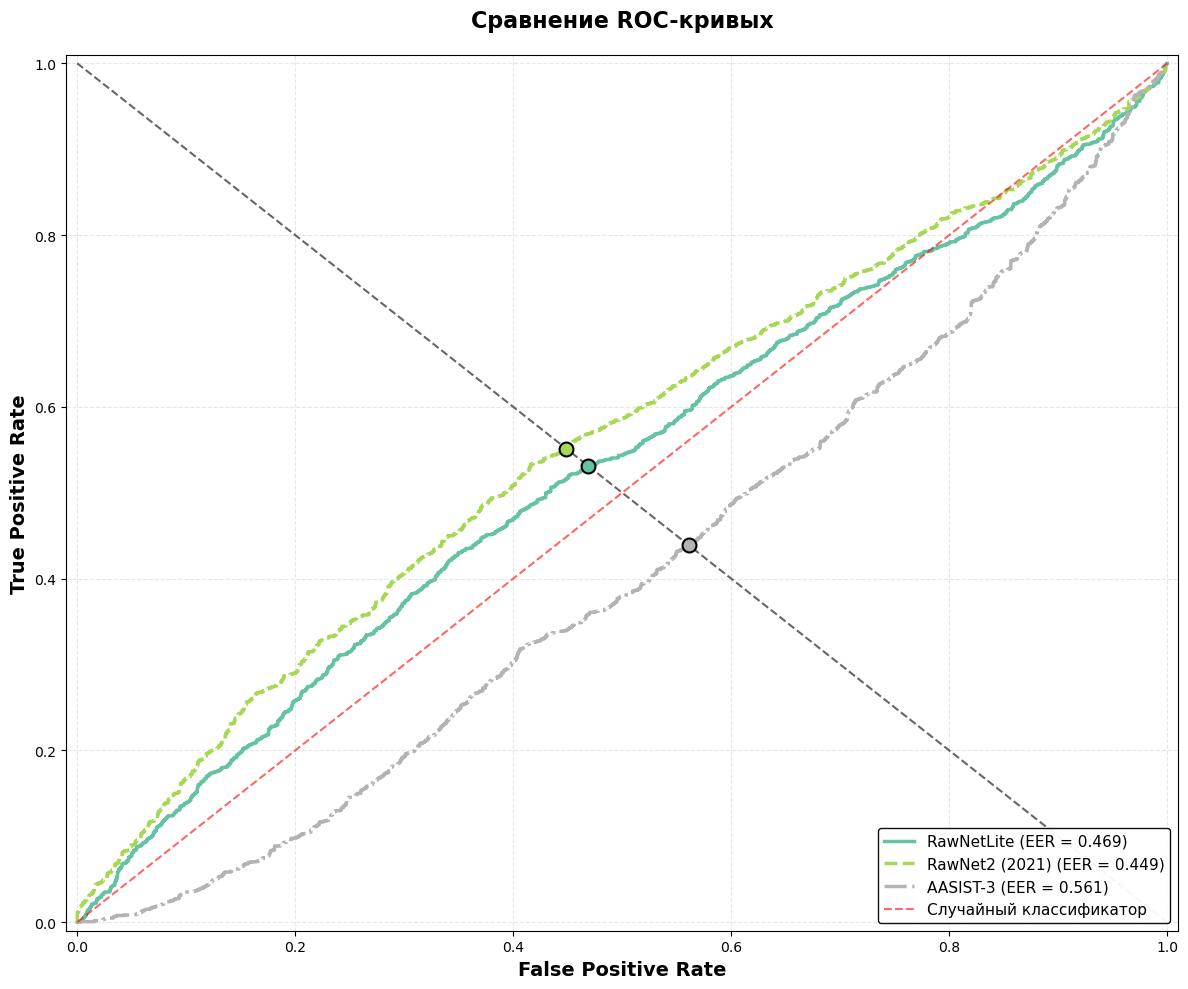

In [28]:
results = visualize_eer(test_df['label'], probas_dict, title="Сравнение ROC-кривых")

In [29]:
results = {
    "RawNetLite": {
        "EER": rawnetlite_test_eer,
        "ROC-AUC": roc_auc_score(test_df['label'], rawnetlite_test_probas),
        "Threshold": rawnetlite_train_thr,
        "Accuracy": rawnetlite_test_accuracy
    },
    "RawNet2": {
        "EER": rawnet2_test_eer,
        "ROC-AUC": roc_auc_score(test_df['label'], rawnet2_test_probas),
        "Threshold": rawnet2_train_thr,
        "Accuracy": rawnet2_test_accuracy
    },
    "AASIST-3": {
        "EER": aasist_test_eer,
        "ROC-AUC": roc_auc_score(test_df['label'], aasist_test_probas),
        "Threshold": aasist_train_thr,
        "Accuracy": aasist_test_accuracy
    }
}

In [30]:
print("="*70)
print(f"{'Model':<25} {'AUC':<10} {'EER':<10} {'Threshold':<15} {'Accuracy':<10}")
print("="*70)
for model in results:
    print(f"{model:<25} {results[model]['ROC-AUC']:<10.4f} {results[model]['EER']:<10.4f} {results[model]['Threshold']:<10.4f} {results[model]['Accuracy']:<10.4f}")
print("="*70)

Model                     AUC        EER        Threshold       Accuracy  
RawNetLite                0.5307     0.4690     0.2466     0.5310    
RawNet2                   0.5588     0.4488     0.0000     0.5515    
AASIST-3                  0.4077     0.5613     0.0000     0.4372    


In [31]:
def visualize_detection_rates(test_df, model_names, figsize=(12, 6)):
    tts_df = test_df[test_df['tts_model'].notna()]
    tts_models = sorted(tts_df['tts_model'].unique())
    
    detection_rates = {}
    
    for model_name in model_names:
        detection_rates[model_name] = []
        
        for tts_model in tts_models:
            df_subset = tts_df[tts_df['tts_model'] == tts_model]
            rate = df_subset[model_name].sum() / len(df_subset) * 100 if len(df_subset) > 0 else 0
            detection_rates[model_name].append(rate)
    
    n_models = len(detection_rates)
    n_tts = len(tts_models)
    
    # Позиции для столбцов
    x = np.arange(n_tts)
    width = 0.8 / n_models  # Ширина столбца
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Цвета для моделей
    colors = plt.cm.Set2(np.linspace(0, 1, n_models))
    
    # Рисуем столбцы для каждой модели
    for i, (model_name, rates) in enumerate(detection_rates.items()):
        offset = (i - n_models/2 + 0.5) * width
        bars = ax.bar(x + offset, rates, width, 
                      label=model_name, color=colors[i], edgecolor='black')
        
        # Добавляем значения над столбцами
        for bar, rate in zip(bars, rates):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                   f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Настройки графика
    ax.set_xlabel('TTS Модели', fontsize=12, fontweight='bold')
    ax.set_ylabel('Доля обнаруженных дипфейков (%)', fontsize=12, fontweight='bold')
    ax.set_title('Эффективность детектирования по TTS-моделям', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(tts_models, rotation=0, fontsize=11)
    ax.set_ylim(0, 105)
    ax.legend(title='Модели детектирования', fontsize=10, title_fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Добавляем горизонтальную линию на 100%
    ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    return detection_rates, tts_models

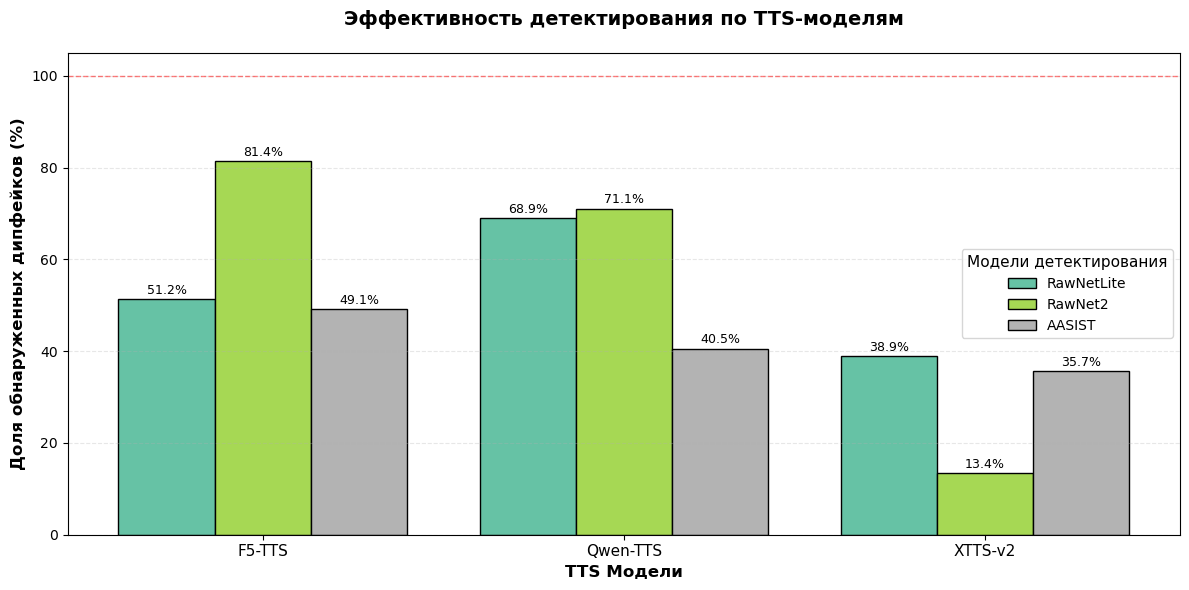

In [32]:
labels_dict = {
    "RawNetLite": rawnetlite_test_predictions,
    "RawNet2": rawnet2_test_predictions,
    "AASIST": aasist_test_predictions
}

for model in labels_dict:
    test_df[model] = labels_dict[model]

model_names = list(labels_dict.keys())
visualize_detection_rates(test_df, model_names);